# 02 — RFM Segmentation & Customer Personas
**Project:** Customer Lifecycle & Campaign Effectiveness Analysis  
**Dataset:** Online Retail II (UCI Machine Learning Repository)  
**Author:** Amrit Sharma  

---

## Objective
Segment customers into actionable personas using RFM (Recency, Frequency, Monetary) analysis.  
RFM is the industry-standard framework used by CRM platforms like **Klaviyo**, **Salesforce Marketing Cloud**, and **HubSpot** to power lifecycle marketing.

This notebook covers:
1. RFM metric calculation per customer
2. RFM scoring (1–5 scale)
3. Customer segmentation into named personas
4. Segment profiling & visualisation
5. Marketing action mapping per segment

---

## 0. Setup & Imports

In [1]:
import os

# ── Path configuration ────────────────────────────────────────────────────────
# This notebook uses relative paths so it runs on any machine.
# BASE_DIR points to the project root folder.
# If running in Jupyter from the notebooks/ folder: BASE_DIR = '..'
# If running in Cursor or VS Code from the project root: BASE_DIR = '.'
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Verify the project structure is correct
print(f'Project root : {BASE_DIR}')
print(f'Data folder  : {os.path.join(BASE_DIR, "data")}')
print(f'Outputs      : {os.path.join(BASE_DIR, "outputs")}')
print(f'Folders exist: data={os.path.exists(os.path.join(BASE_DIR, "data"))}, outputs={os.path.exists(os.path.join(BASE_DIR, "outputs"))}')

Project root : /Users/amrit/Desktop/Customer Lifecycle Analysis Project
Data folder  : /Users/amrit/Desktop/Customer Lifecycle Analysis Project/data
Outputs      : /Users/amrit/Desktop/Customer Lifecycle Analysis Project/outputs
Folders exist: data=True, outputs=True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#F59E0B', '#7C3AED', '#0891B2', '#DB2777']

# Segment colour map — used consistently across all charts
SEGMENT_COLOURS = {
    'Champions':        '#16A34A',
    'Loyal Customers':  '#2563EB',
    'Potential Loyal':  '#0891B2',
    'At Risk':          '#F59E0B',
    'Need Attention':   '#DB2777',
    'Lost':             '#DC2626',
    'New Customers':    '#7C3AED',
}

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Clean Data

In [3]:
import os
print(os.getcwd())
print(BASE_DIR)

/Users/amrit/Desktop/Customer Lifecycle Analysis Project/notebooks
/Users/amrit/Desktop/Customer Lifecycle Analysis Project


In [4]:
CLEAN_PATH = os.path.join(BASE_DIR, 'data', 'online_retail_clean.csv')

df = pd.read_csv(CLEAN_PATH, dtype={'Customer ID': str}, parse_dates=['InvoiceDate'])

print(f'Rows loaded      : {len(df):,}')
print(f'Unique customers : {df["Customer ID"].nunique():,}')
print(f'Date range       : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')

Rows loaded      : 779,425
Unique customers : 5,878
Date range       : 2009-12-01 → 2011-12-09


## 2. Calculate RFM Metrics

**RFM stands for:**
- **Recency (R)** — How many days since the customer last purchased? Lower = better.
- **Frequency (F)** — How many unique orders has the customer placed? Higher = better.
- **Monetary (M)** — How much total revenue has the customer generated? Higher = better.

We calculate these at **customer level** — one row per customer.

In [5]:
# ── Snapshot date: 1 day after the last transaction in the dataset ─────────────
# This acts as "today" for recency calculation
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date (reference point for recency): {snapshot_date.date()}')

# ── Calculate RFM per customer ─────────────────────────────────────────────────
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',      'nunique'),
    Monetary  = ('TotalRevenue', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f'\nRFM table shape  : {rfm.shape}')
print(f'\nRFM Summary Statistics:')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Snapshot date (reference point for recency): 2011-12-10

RFM table shape  : (5878, 4)

RFM Summary Statistics:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


In [6]:
rfm.head(10)

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


## 3. RFM Scoring (1–5)

We convert the raw RFM values into scores from **1 to 5** using quintiles (equal-sized buckets).

- **Recency:** Score 5 = bought most recently (lowest recency days). Note: reversed scale.
- **Frequency:** Score 5 = ordered most often.
- **Monetary:** Score 5 = spent the most.

This normalises all three dimensions onto the same scale for fair comparison.

In [7]:
# ── Score each dimension 1–5 using pd.qcut (quantile-based binning) ────────────

# Recency: LOWER days = BETTER = higher score (so we reverse with labels[::-1])
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1], duplicates='drop').astype(int)

# Frequency: HIGHER orders = BETTER = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

# Monetary: HIGHER spend = BETTER = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

# ── Composite RFM Score (simple average) ──────────────────────────────────────
rfm['RFM_Score'] = (rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']) / 3
rfm['RFM_Score'] = rfm['RFM_Score'].round(2)

# ── String label for easy reading e.g. "5-4-3" ───────────────────────────────
rfm['RFM_Label'] = rfm['R_Score'].astype(str) + '-' + rfm['F_Score'].astype(str) + '-' + rfm['M_Score'].astype(str)

print('RFM scoring complete ✓')
print(rfm[['Customer ID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']].head(10))

RFM scoring complete ✓
  Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326         12  77556.46        2        5        5   
1       12347        2          8   4921.53        5        4        5   
2       12348       75          5   2019.40        3        4        4   
3       12349       19          4   4428.69        5        3        5   
4       12350      310          1    334.40        2        1        2   
5       12351      375          1    300.93        2        1        2   
6       12352       36         10   2849.84        4        5        4   
7       12353      204          2    406.76        2        2        2   
8       12354      232          1   1079.40        2        1        3   
9       12355      214          2    947.61        2        2        3   

   RFM_Score  
0       4.00  
1       4.67  
2       3.67  
3       4.33  
4       1.67  
5       1.67  
6       4.33  
7       2.00  
8       2.00  
9       2.33

## 4. Customer Segmentation

Using R and F scores (the two strongest behavioural signals), we assign each customer to a named segment.  
These segments map directly to **Klaviyo lifecycle flows** and **Google Ads audience lists**.

In [8]:
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyal'
    elif r == 1 and f >= 4:
        return 'At Risk'
    elif r == 2 and f >= 3:
        return 'Need Attention'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'New Customers'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# ── Segment summary ───────────────────────────────────────────────────────────
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('Customer ID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean'),
    Total_Revenue  = ('Monetary',   'sum')
).round(2).reset_index()

segment_summary['Revenue_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)
segment_summary['Customer_%'] = (segment_summary['Customer_Count'] / segment_summary['Customer_Count'].sum() * 100).round(1)

print('=== Segment Summary ===')
print(segment_summary.sort_values('Total_Revenue', ascending=False).to_string(index=False))

=== Segment Summary ===
        Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_%  Customer_%
      Champions            1482        20.37          15.66       8113.58    12024330.14       69.2        25.2
Loyal Customers            1221        78.57           5.42       2055.73     2510046.34       14.4        20.8
 Need Attention             551       303.15           5.19       2049.61     1129337.08        6.5         9.4
           Lost            1523       459.28           1.25        429.70      654426.70        3.8        25.9
Potential Loyal             828        64.84           1.41        720.55      596616.76        3.4        14.1
        At Risk              89       493.03           7.54       3027.56      269452.77        1.6         1.5
  New Customers             184       506.64           2.93       1035.84      190594.46        1.1         3.1


## 5. Visualisations

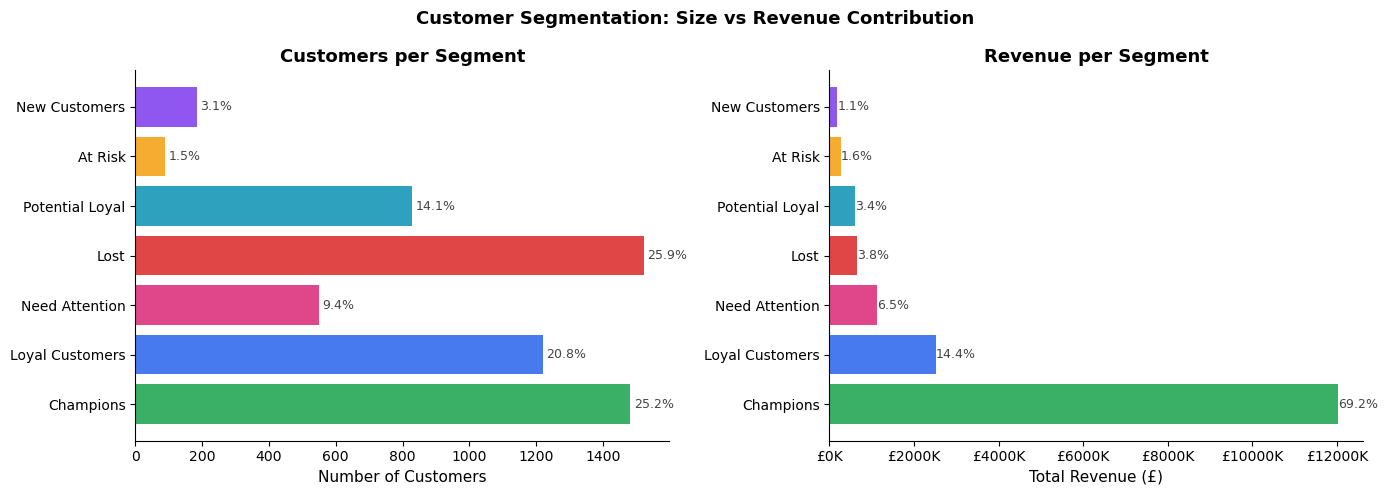

Chart saved ✓


In [9]:
# ── 5.1 Segment Size — Customer Count & Revenue Share ────────────────────────
seg = segment_summary.sort_values('Total_Revenue', ascending=False)
colours = [SEGMENT_COLOURS.get(s, '#999') for s in seg['Segment']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count
axes[0].barh(seg['Segment'], seg['Customer_Count'], color=colours, alpha=0.85)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for i, (v, pct) in enumerate(zip(seg['Customer_Count'], seg['Customer_%'])):
    axes[0].text(v + 10, i, f'{pct}%', va='center', fontsize=9, color='#444')

# Revenue share
axes[1].barh(seg['Segment'], seg['Total_Revenue'], color=colours, alpha=0.85)
axes[1].set_title('Revenue per Segment', fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for i, (v, pct) in enumerate(zip(seg['Total_Revenue'], seg['Revenue_%'])):
    axes[1].text(v + 1000, i, f'{pct}%', va='center', fontsize=9, color='#444')

plt.suptitle('Customer Segmentation: Size vs Revenue Contribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'segment_size_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

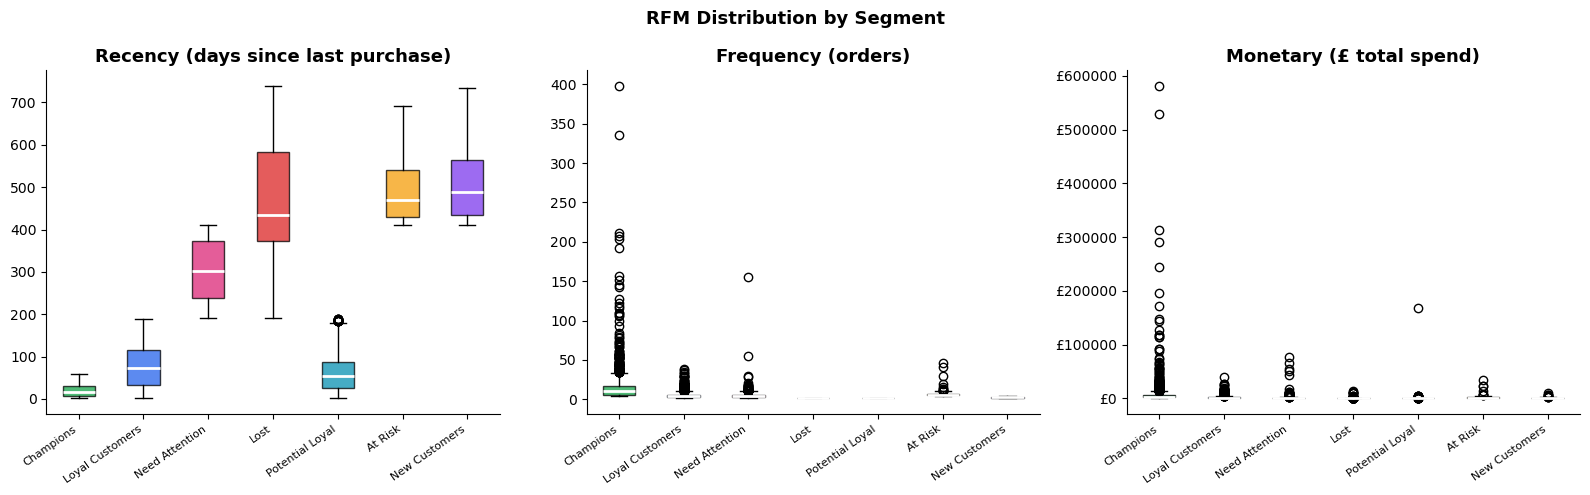

In [10]:
# ── 5.2 RFM Distribution per Segment (Box plots) ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Recency', 'Frequency', 'Monetary']
titles  = ['Recency (days since last purchase)', 'Frequency (orders)', 'Monetary (£ total spend)']

seg_order = segment_summary.sort_values('Total_Revenue', ascending=False)['Segment'].tolist()

for ax, metric, title in zip(axes, metrics, titles):
    data_by_seg = [rfm[rfm['Segment'] == s][metric].values for s in seg_order]
    bp = ax.boxplot(data_by_seg, patch_artist=True, vert=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, seg_name in zip(bp['boxes'], seg_order):
        patch.set_facecolor(SEGMENT_COLOURS.get(seg_name, '#999'))
        patch.set_alpha(0.75)
    ax.set_xticklabels(seg_order, rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    if metric == 'Monetary':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))

plt.suptitle('RFM Distribution by Segment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'rfm_distribution_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

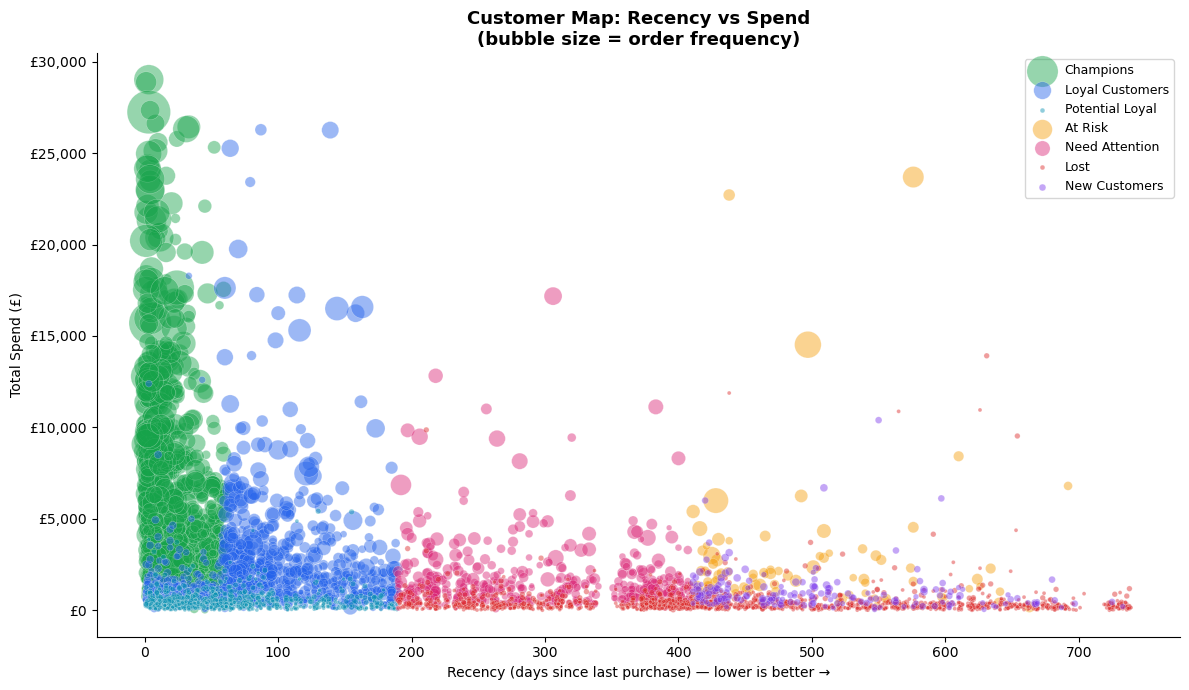


💡 Champions cluster: low recency (bought recently) + high spend + large bubbles (frequent)
💡 Lost cluster: high recency (not bought in a long time) + low spend


In [11]:
# ── 5.3 Recency vs Monetary scatter (sized by Frequency) ─────────────────────
# Cap monetary at 99th percentile to avoid extreme outliers dominating the chart
cap = rfm['Monetary'].quantile(0.99)
rfm_plot = rfm[rfm['Monetary'] <= cap].copy()

fig, ax = plt.subplots(figsize=(12, 7))

for seg_name, colour in SEGMENT_COLOURS.items():
    subset = rfm_plot[rfm_plot['Segment'] == seg_name]
    ax.scatter(
        subset['Recency'],
        subset['Monetary'],
        s=subset['Frequency'] * 8,
        c=colour,
        alpha=0.45,
        label=seg_name,
        edgecolors='white',
        linewidth=0.3
    )

ax.set_xlabel('Recency (days since last purchase) — lower is better →', fontsize=10)
ax.set_ylabel('Total Spend (£)', fontsize=10)
ax.set_title('Customer Map: Recency vs Spend\n(bubble size = order frequency)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'customer_map_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Champions cluster: low recency (bought recently) + high spend + large bubbles (frequent)')
print('💡 Lost cluster: high recency (not bought in a long time) + low spend')

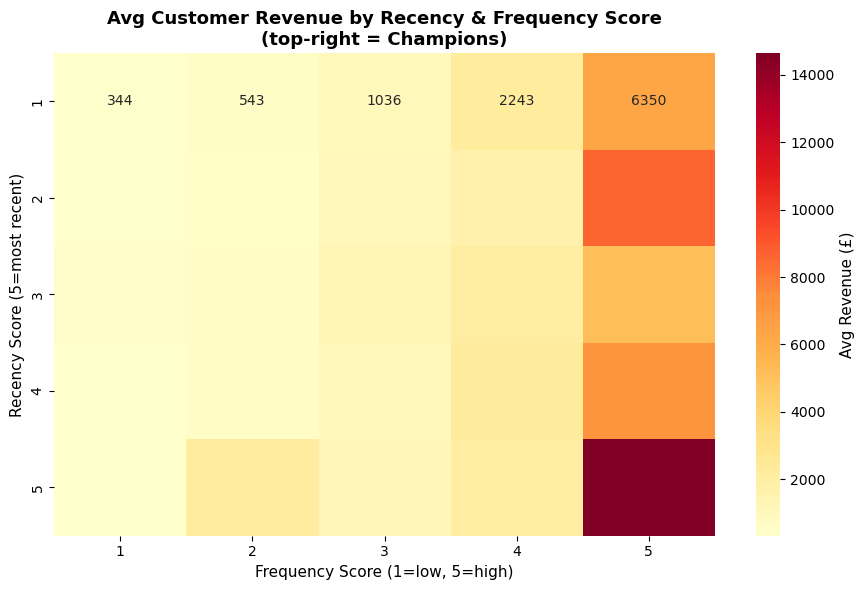


 Top-right corner (R=5, F=5) = Champions — highest average revenue, most recent & frequent buyers.


In [12]:
# ── 5.4 RFM Score Heatmap (R vs F, colour = avg Monetary) ────────────────────
heatmap_data = rfm.groupby(['R_Score', 'F_Score'])['Monetary'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Avg Revenue (£)'}
)
ax.set_title('Avg Customer Revenue by Recency & Frequency Score\n(top-right = Champions)', fontweight='bold')
ax.set_xlabel('Frequency Score (1=low, 5=high)')
ax.set_ylabel('Recency Score (5=most recent)')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'rfm_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n Top-right corner (R=5, F=5) = Champions — highest average revenue, most recent & frequent buyers.')

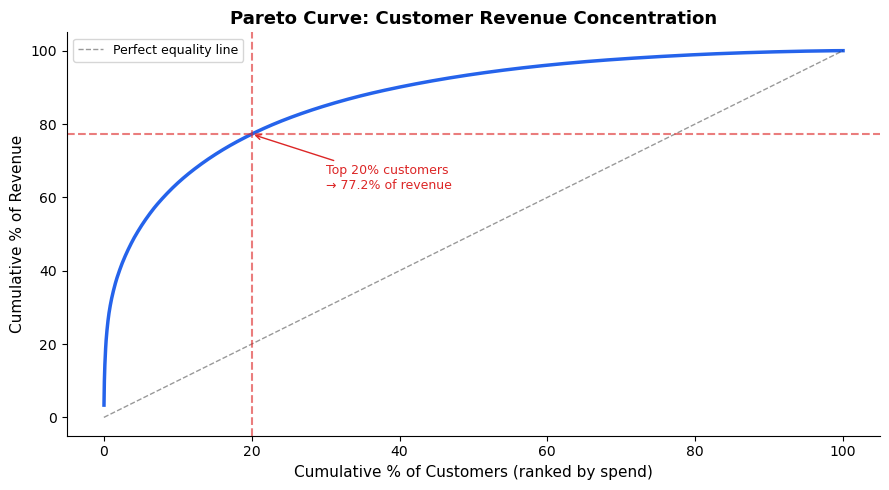


 Top 20% of customers generate 77.2% of total revenue — classic Pareto effect.
   This is the business case for differentiated CRM strategy.


In [13]:
# ── 5.5 Pareto Analysis: % of customers vs % of revenue ──────────────────────
rfm_sorted = rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)
rfm_sorted['cum_revenue_pct']   = rfm_sorted['Monetary'].cumsum() / rfm_sorted['Monetary'].sum() * 100
rfm_sorted['cum_customer_pct']  = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rfm_sorted['cum_customer_pct'], rfm_sorted['cum_revenue_pct'],
        color=PALETTE[0], linewidth=2.5)
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, alpha=0.4, label='Perfect equality line')

# Mark the 20% customer point
idx_20 = rfm_sorted[rfm_sorted['cum_customer_pct'] <= 20].index[-1]
rev_at_20 = rfm_sorted.loc[idx_20, 'cum_revenue_pct']
ax.axvline(x=20, color=PALETTE[2], linestyle='--', alpha=0.6)
ax.axhline(y=rev_at_20, color=PALETTE[2], linestyle='--', alpha=0.6)
ax.annotate(f'Top 20% customers\n→ {rev_at_20:.1f}% of revenue',
            xy=(20, rev_at_20), xytext=(30, rev_at_20 - 15),
            fontsize=9, color=PALETTE[2],
            arrowprops=dict(arrowstyle='->', color=PALETTE[2]))

ax.set_xlabel('Cumulative % of Customers (ranked by spend)')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Pareto Curve: Customer Revenue Concentration', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'pareto_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\n Top 20% of customers generate {rev_at_20:.1f}% of total revenue — classic Pareto effect.')
print('   This is the business case for differentiated CRM strategy.')

## 6. Segment Profiles & Marketing Action Map

| Segment | Behaviour Profile | Klaviyo Flow | Google Ads Strategy |
|---|---|---|---|
| **Champions** | Bought recently, buy often, spend most | VIP loyalty flow, early access emails | Exclude from acquisition, use as lookalike seed |
| **Loyal Customers** | Regular buyers, solid spend | Upsell / cross-sell flow, reward emails | Upsell remarketing campaign |
| **Potential Loyal** | Recent buyers, low frequency | Nurture sequence, product education | Retargeting with complementary products |
| **At Risk** | Used to buy often, haven't recently | Win-back flow: 'We miss you' + offer | Win-back display campaign with discount |
| **Need Attention** | Declining engagement | Re-engagement flow with urgency | RLSA bid boost for search campaigns |
| **Lost** | Haven't bought in a long time | Final win-back, then suppress | Exclude from paid (wasted spend) |
| **New Customers** | First purchase only | Welcome series, second purchase incentive | Similar audience expansion |

In [14]:
# ── Print key numbers to populate strategy doc ────────────────────────────────
print('=== KEY NUMBERS FOR STRATEGY RECOMMENDATIONS ===')
for _, row in segment_summary.sort_values('Total_Revenue', ascending=False).iterrows():
    print(f"""
Segment        : {row['Segment']}
  Customers    : {int(row['Customer_Count']):,} ({row['Customer_%']}% of base)
  Revenue      : £{row['Total_Revenue']:,.0f} ({row['Revenue_%']}% of total)
  Avg Recency  : {row['Avg_Recency']:.0f} days
  Avg Orders   : {row['Avg_Frequency']:.1f}
  Avg Spend    : £{row['Avg_Monetary']:,.0f}
""")

=== KEY NUMBERS FOR STRATEGY RECOMMENDATIONS ===

Segment        : Champions
  Customers    : 1,482 (25.2% of base)
  Revenue      : £12,024,330 (69.2% of total)
  Avg Recency  : 20 days
  Avg Orders   : 15.7
  Avg Spend    : £8,114


Segment        : Loyal Customers
  Customers    : 1,221 (20.8% of base)
  Revenue      : £2,510,046 (14.4% of total)
  Avg Recency  : 79 days
  Avg Orders   : 5.4
  Avg Spend    : £2,056


Segment        : Need Attention
  Customers    : 551 (9.4% of base)
  Revenue      : £1,129,337 (6.5% of total)
  Avg Recency  : 303 days
  Avg Orders   : 5.2
  Avg Spend    : £2,050


Segment        : Lost
  Customers    : 1,523 (25.9% of base)
  Revenue      : £654,427 (3.8% of total)
  Avg Recency  : 459 days
  Avg Orders   : 1.2
  Avg Spend    : £430


Segment        : Potential Loyal
  Customers    : 828 (14.1% of base)
  Revenue      : £596,617 (3.4% of total)
  Avg Recency  : 65 days
  Avg Orders   : 1.4
  Avg Spend    : £721


Segment        : At Risk
  Customer

## 7. Save RFM Output

In [15]:
OUTPUT_PATH = os.path.join(BASE_DIR, 'data', 'rfm_segments.csv')
rfm.to_csv(OUTPUT_PATH, index=False)
print(f'✓ RFM segments saved → {OUTPUT_PATH}')
print(f'  Shape  : {rfm.shape}')
print(f'  Columns: {list(rfm.columns)}')
print(f'\n✓ Segments in file: {rfm["Segment"].value_counts().to_dict()}')

✓ RFM segments saved → /Users/amrit/Desktop/Customer Lifecycle Analysis Project/data/rfm_segments.csv
  Shape  : (5878, 10)
  Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Label', 'Segment']

✓ Segments in file: {'Lost': 1523, 'Champions': 1482, 'Loyal Customers': 1221, 'Potential Loyal': 828, 'Need Attention': 551, 'New Customers': 184, 'At Risk': 89}
